In [1]:
import yfinance as yf
import matplotlib.pyplot as plt
from IPython.display import display, clear_output
import time
import random  # Added for simulation
import finance_core

In [2]:
cpp_tools = finance_core.FinancialTools()

ticker = "AAPL"
window_size = 5
loop_interval = 2  # Faster updates for testing

In [3]:
# --- SIMULATION SWITCH ---
# Set this to True to fake the data movement (since market is closed)
# Set this to False when the market is actually open
SIMULATION_MODE = True 
# -------------------------

In [4]:
print(f"Starting feed for {ticker} (Simulation: {SIMULATION_MODE})...")

Starting feed for AAPL (Simulation: True)...


In [5]:
data = yf.download(ticker, period="1d", interval="1m", progress=False)

In [6]:
# Clean data format (handle different yfinance versions)
if data.ndim > 1 and 'Close' in data:
    prices = data['Close'].iloc[:, 0].tolist()
else:
    prices = data['Close'].tolist()

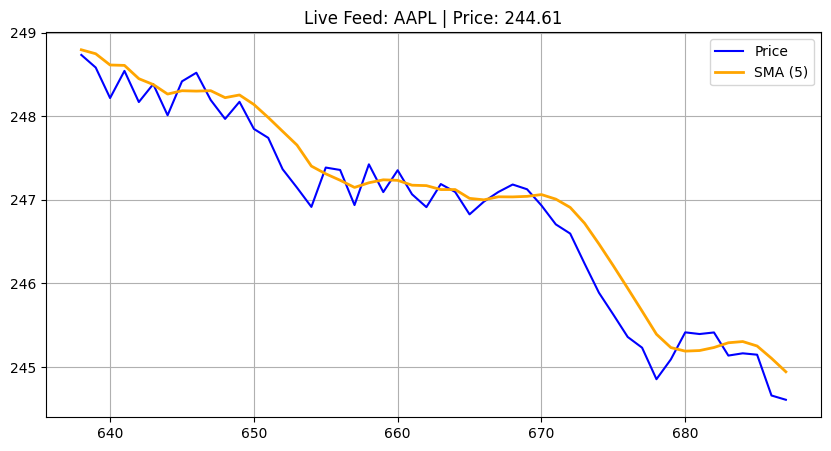

Stopped.


In [9]:
try:
    while True:
        # GET DATA
        if SIMULATION_MODE:
            # IF MARKET CLOSED FAKE DATA
            last_price = prices[-1]
            change = random.uniform(-0.5, 0.5) # Random move up or down
            new_price = last_price + change
            prices.append(new_price) # Add some shit
        else:
            # REAL MODE: 
            data = yf.download(ticker, period="1d", interval="1m", progress=False)
            if not data.empty:
                prices = data['Close'].iloc[:, 0].tolist()

        #  C++ CALCULATION 
        # Pass the growing list of prices to your C++ logic
        sma_values = cpp_tools.calculate_sma(prices, window_size)

        #  3. PLOTTING 
        clear_output(wait=True)
        
        plt.figure(figsize=(10, 5))
        
        # Show only the last 50 points so the movement is obvious
        display_range = 50
        
        # Ensure we don't crash if we have less than 50 points
        start_idx = max(0, len(prices) - display_range)
        
        # Plot Prices
        plt.plot(range(start_idx, len(prices)), prices[start_idx:], 
                 label="Price", color='blue')
        
        # Plot SMA (Align it with prices)
        # SMA array is shorter, so we offset the x-axis
        if len(sma_values) > 0:
            sma_start_idx = len(prices) - len(sma_values)
            visible_sma_start = max(0, start_idx - sma_start_idx)
            
            plt.plot(range(sma_start_idx + visible_sma_start, len(prices)), 
                     sma_values[visible_sma_start:], 
                     label=f"SMA ({window_size})", color='orange', linewidth=2)

        plt.title(f"Live Feed: {ticker} | Price: {prices[-1]:.2f}")
        plt.legend()
        plt.grid(True)
        plt.show()

        time.sleep(loop_interval)

except KeyboardInterrupt:
    print("Stopped.")